In [73]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import os

def parse_and_process_files(file_x, file_z, target_decoder):
    def manual_parse(filepath):
        rows = []
        with open(filepath, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            # Skip empty lines
            if not line.strip(): 
                continue
            
            # Skip the header row
            if line.strip().startswith('shots'):
                continue
                
            parts = line.split(',')
            
            decoder_val = parts[4].strip()
            if decoder_val != target_decoder:
                continue
                
            shots, errors = int(parts[0].strip()), int(parts[1].strip())
            
            # Extract parameters using regex due to the embedded JSON string
            p_match = re.search(r'""p"":([0-9.]+)', line)
            p_val = float(p_match.group(1)) if p_match else None
            
            cycle_match = re.search(r'""NumberofCycle"":([0-9]+)', line)
            cycles = int(cycle_match.group(1)) if cycle_match else 10
            
            rows.append({'shots': shots, 'errors': errors, 'p': p_val, 'cycles': cycles})
            
        return pd.DataFrame(rows)

    # Parse the files
    df_x = manual_parse(file_x)
    df_z = manual_parse(file_z)
    
    # Process logical error rates and uncertainties
    for d in [df_x, df_z]:
        if d.empty: continue
        p_fail = d['errors'] / d['shots']
        safe_p_fail_calc = np.minimum(p_fail, 1.0 - 1e-10)
        d['pL'] = 1 - (1 - safe_p_fail_calc)**(1/d['cycles'])
        
        safe_errors = np.maximum(d['errors'], 1)
        safe_p_fail = safe_errors / d['shots']
        base_err = np.sqrt(safe_p_fail * (1 - safe_p_fail) / d['shots'])
        
        d['pL_err'] = (1/d['cycles']) * (1 - safe_p_fail_calc)**(1/d['cycles']-1) * base_err

    if df_x.empty or df_z.empty:
        return pd.DataFrame()

    # Merge and calculate total error rates
    df = pd.merge(df_x[['p', 'pL', 'pL_err']], df_z[['p', 'pL', 'pL_err']], on='p', suffixes=('_x', '_z'))
    
    df['total_pL'] = 1 - (1 - df['pL_x']) * (1 - df['pL_z'])
    df['total_pL_err'] = np.sqrt(((1 - df['pL_z']) * df['pL_err_x'])**2 + ((1 - df['pL_x']) * df['pL_err_z'])**2)
    
    return df.sort_values('p')

def get_fit_params(df, k, d_circ):
    # =========================================================================
    # 0. SAFETY FILTER: Remove rows where pL is 0 (prevents np.log(0) -> -Inf)
    # =========================================================================
    df_valid = df[df['total_pL'] > 0].copy()
    
    # =========================================================================
    # Phase 1: Pseudo-Threshold Fit (Log-Log Space, Weighted)
    # =========================================================================
    log_p = np.log(df_valid['p'].values)
    pL = df_valid['total_pL'].values
    pL_err = df_valid['total_pL_err'].values
    
    # Propagate standard error into the logarithmic domain: sigma_ln(x) = sigma_x / x
    log_pL_err = np.maximum(pL_err, 1e-15) / pL
    
    # NumPy's polyfit expects weights to be inversely proportional to the variance/stddev
    weights = 1.0 / log_pL_err
    
    # Fit the polynomial using the statistical weights
    #poly_coeffs = np.polyfit(log_p, np.log(pL), 2, w=weights)
    poly_coeffs = np.polyfit(log_p, np.log(pL), 2)
    poly = np.poly1d(poly_coeffs)
    
    # Find the break-even intersection to get the pseudo-threshold
    p_ps = fsolve(lambda p: np.exp(poly(np.log(p))) - (1 - (1 - p)**k), 0.0055)[0]
    
    # =========================================================================
    # Phase 2: Sub-Threshold Scaling Fit (Weighted)
    # =========================================================================
    df_sub = df_valid[df_valid['p'] < p_ps]
    p_s = df_sub['p'].values
    pL_s = df_sub['total_pL'].values
    pL_err_s = df_sub['total_pL_err'].values
    
    exponent = d_circ / 2.0
    
    # The y-variable we are fitting
    y = np.log(pL_s) - exponent * np.log(p_s)
    
    y_err = np.maximum(pL_err_s, 1e-15) / pL_s
    weights_sub = 1.0 / y_err
    
    # Fit the sub-threshold data using the weights
    c2, c1, c0 = np.polyfit(p_s, y, 2, w=weights_sub)
    
    return p_ps, (c0, c1, c2), exponent

In [74]:
# Define the folder
folder = 'sinter_results'

# 1. Map the exact file paths from your folder
file_48_x = os.path.join(folder, 'results_code_n48_k8_d6_l384_m512_s53_a1_34_48_b1_6_12_X.csv')
file_48_z = os.path.join(folder, 'results_code_n48_k8_d6_l384_m512_s53_a1_34_48_b1_6_12_Z.csv')

file_84_x = os.path.join(folder, 'results_code_n84_k16_d8_l252_m21_s6_a1_14_71_89_b1_6_8_19_X.csv')
file_84_z = os.path.join(folder, 'results_code_n84_k16_d8_l252_m21_s6_a1_14_71_89_b1_6_8_19_Z.csv')

file_96_x = os.path.join(folder, 'results_code_n96_k8_d10_l384_m512_s27_a1_9_87_b1_21_23_X.csv')
file_96_z = os.path.join(folder, 'results_code_n96_k8_d10_l384_m512_s27_a1_9_87_b1_21_23_Z.csv')

file_112_x = os.path.join(folder, 'results_code_n112_k16_d10_l224_m53_s9_a1_11_59_81_b1_15_23_25_X.csv')
file_112_z = os.path.join(folder, 'results_code_n112_k16_d10_l224_m53_s9_a1_11_59_81_b1_15_23_25_Z.csv')

file_128_x = os.path.join(folder, 'results_code_n128_k16_d12_l128_m10_s1_a1_47_75_88_b1_8_12_19_X.csv')
file_128_z = os.path.join(folder, 'results_code_n128_k16_d12_l128_m10_s1_a1_47_75_88_b1_8_12_19_Z.csv')

file_168_x = os.path.join(folder, 'results_code_n168_k16_d15_l168_m33_s1_a1_72_106_109_b1_11_18_26_X.csv')
file_168_z = os.path.join(folder, 'results_code_n168_k16_d15_l168_m33_s1_a1_72_106_109_b1_11_18_26_Z.csv')

file_224_x = os.path.join(folder, 'results_code_n224_k12_d16_l224_m53_s1_a1_81_186_b1_16_47_X.csv')
file_224_z = os.path.join(folder, 'results_code_n224_k12_d16_l224_m53_s1_a1_81_186_b1_16_47_Z.csv')

# 2. bposd Decoder Processings
df48 = parse_and_process_files(file_48_x, file_48_z, 'bposd')
p_ps48, coeffs48, exp48 = get_fit_params(df48, k=8, d_circ=5)

df84 = parse_and_process_files(file_84_x, file_84_z, 'bposd')
p_ps84, coeffs84, exp84 = get_fit_params(df84, k=16, d_circ=7)

df96 = parse_and_process_files(file_96_x, file_96_z, 'bposd')
p_ps96, coeffs96, exp96 = get_fit_params(df96, k=8, d_circ=9)

df112 = parse_and_process_files(file_112_x, file_112_z, 'bposd')
p_ps112, coeffs112, exp112 = get_fit_params(df112, k=16, d_circ=8)

df128 = parse_and_process_files(file_128_x, file_128_z, 'bposd')
p_ps128, coeffs128, exp128 = get_fit_params(df128, k=16, d_circ=10)

df168 = parse_and_process_files(file_168_x, file_168_z, 'bposd')
p_ps168, coeffs168, exp168 = get_fit_params(df168, k=16, d_circ=13)

df224 = parse_and_process_files(file_224_x, file_224_z, 'bposd')
p_ps224, coeffs224, exp224 = get_fit_params(df224, k=12, d_circ=14)

# 3. beam32_340iters Decoder Processings
df_48_beam = parse_and_process_files(file_48_x, file_48_z, 'beam32_340iters')
p_ps48_beam, coeffs48_beam, exp48_beam = get_fit_params(df_48_beam, k=8, d_circ=5)

df_96_beam = parse_and_process_files(file_96_x, file_96_z, 'beam32_340iters')
p_ps96_beam, coeffs96_beam, exp96_beam = get_fit_params(df_96_beam, k=8, d_circ=9)

df_128_beam = parse_and_process_files(file_128_x, file_128_z, 'beam32_340iters')
p_ps128_beam, coeffs128_beam, exp128_beam = get_fit_params(df_128_beam, k=16, d_circ=10)

# 4. relay-bp_5 Decoder Processings
df_48_relay = parse_and_process_files(file_48_x, file_48_z, 'relay-bp_5')
p_ps48_relay, coeffs48_relay, exp48_relay = get_fit_params(df_48_relay, k=8, d_circ=5)

df_96_relay = parse_and_process_files(file_96_x, file_96_z, 'relay-bp_5')
p_ps96_relay, coeffs96_relay, exp96_relay = get_fit_params(df_96_relay, k=8, d_circ=9)

df_128_relay = parse_and_process_files(file_128_x, file_128_z, 'relay-bp_5')
p_ps128_relay, coeffs128_relay, exp128_relay = get_fit_params(df_128_relay, k=16, d_circ=10)

In [75]:
print(f"[48, 8, 6] Pseudo-threshold: {p_ps48:.5f}")
print(f"[96, 8, 10] Pseudo-threshold: {p_ps96:.5f}")
print(f"[128, 16, 12] Pseudo-threshold: {p_ps128:.5f}")
print(f"[224, 12, 16] Pseudo-threshold: {p_ps224:.5f}")
print(f"[168, 16, 15] Pseudo-threshold: {p_ps168:.5f}")
print(f"[84, 16, 8] Pseudo-threshold: {p_ps84:.5f}")
print(f"[112, 16, 10] Pseudo-threshold: {p_ps112:.5f}")

[48, 8, 6] Pseudo-threshold: 0.00356
[96, 8, 10] Pseudo-threshold: 0.00466
[128, 16, 12] Pseudo-threshold: 0.00360
[224, 12, 16] Pseudo-threshold: 0.00540
[168, 16, 15] Pseudo-threshold: 0.00363
[84, 16, 8] Pseudo-threshold: 0.00346
[112, 16, 10] Pseudo-threshold: 0.00340


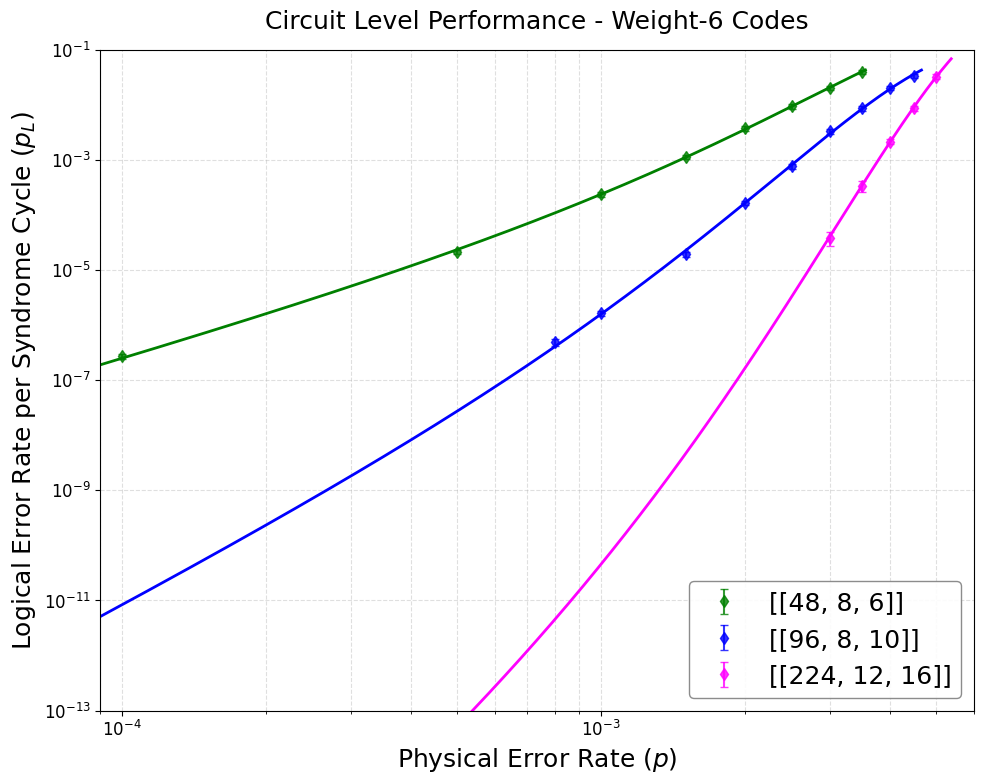

In [76]:
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(10, 8)) 

x_min, x_max = 9e-5, 0.006
p_fine = np.logspace(np.log10(x_min), np.log10(x_max), 500)

def extrap(p, c, e): 
    return (p**e) * np.exp(c[0] + c[1]*p + c[2]*p**2)

# Replaced 'y' (yellow) with 'orange' for contrast against white backgrounds
configs = [
    (df48,  p_ps48,  coeffs48,  exp48,  'green',   'd', '[[48, 8, 6]]',    8),
    (df96,  p_ps96,  coeffs96,  exp96,  'blue',    'd', '[[96, 8, 10]]',   8),
    (df224, p_ps224, coeffs224, exp224, 'magenta', 'd', '[[224, 12, 16]]', 12)
]

for df, p_ps, coeffs, exp, color, marker, lbl, k_val in configs:
    # Filter sub-threshold data
    df_plot = df[(df['p'] < p_ps) & (df['p'] >= x_min) & (df['p'] <= x_max)]
    
    # Plot data points with error bars
    plt.errorbar(df_plot['p'], df_plot['total_pL'], yerr=df_plot['total_pL_err'], 
                 fmt=marker, color=color, capsize=3, alpha=0.8, label=lbl, markersize=6)
    
    # Plot extrapolation only up to p_ps
    p_fine_sub = p_fine[p_fine <= p_ps]
    plt.plot(p_fine_sub, extrap(p_fine_sub, coeffs, exp), '-', color=color, linewidth=2)
    
    # Plot 1 - (1 - p)^k break-even line
    #plt.plot(p_fine, 1 - (1 - p_fine)**k_val, '--', color=color, alpha=0.25)

# Formatting
plt.xscale('log')
plt.yscale('log')
plt.xlim(x_min, x_max)
plt.ylim(1e-13, 1e-1)

plt.title('Circuit Level Performance - Weight-6 Codes', fontsize=18, pad=15)
plt.xlabel('Physical Error Rate ($p$)', fontsize=18)
plt.ylabel('Logical Error Rate per Syndrome Cycle ($p_L$)', fontsize=18)

# Keep legend tidy and easily readable
plt.legend(loc='lower right', fontsize=18, framealpha=0.9, edgecolor='gray')
plt.grid(True, which="both", ls="--", alpha=0.4)

# Prevents axes and labels from being cropped during export
plt.tight_layout() 

# Tip: If you want to save this for your paper, run this before plt.show():
#plt.savefig("plot_weight_6_paper.pdf", dpi=600, bbox_inches='tight')

plt.show()

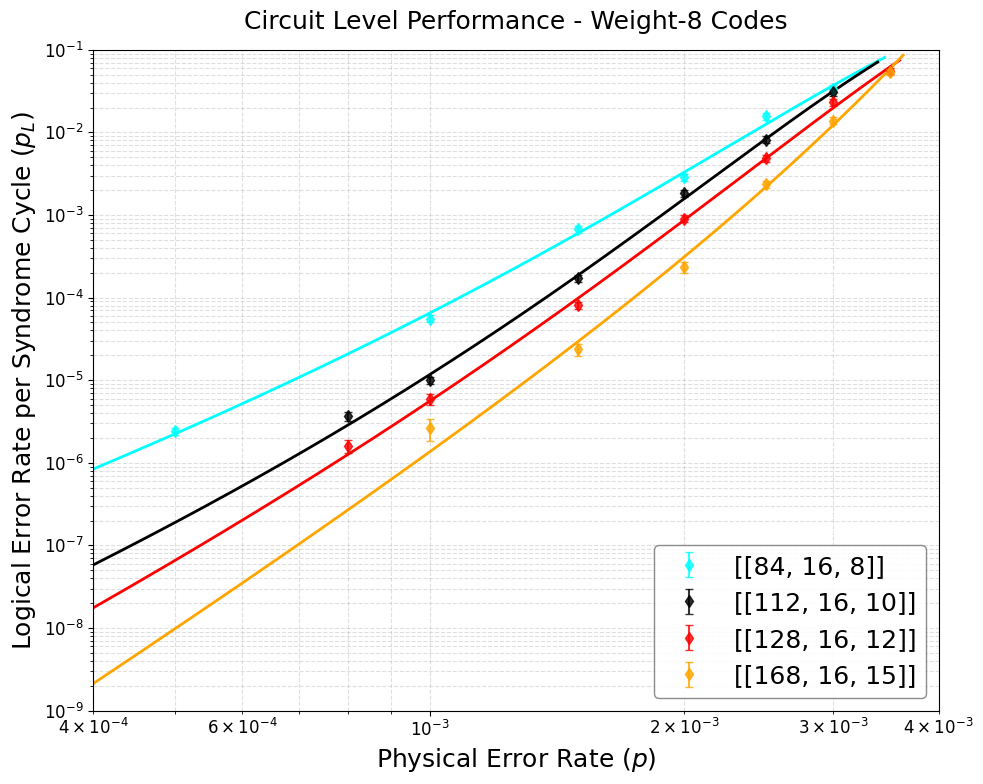

In [77]:
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(10, 8)) 

x_min, x_max = 40e-5, 0.004
p_fine = np.logspace(np.log10(x_min), np.log10(x_max), 500)

def extrap(p, c, e): 
    return (p**e) * np.exp(c[0] + c[1]*p + c[2]*p**2)

# Replaced 'y' (yellow) with 'orange' for contrast against white backgrounds
configs = [
    #(df48,  p_ps48,  coeffs48,  exp48,  'green',   'd', '[48, 8, 6]-weight 6',    8),
    #(df96,  p_ps96,  coeffs96,  exp96,  'blue',    'd', '[96, 8, 10]-weight 6',   8),
    #(df224, p_ps224, coeffs224, exp224, 'magenta', 'd', '[224, 12, 16]-weight 6', 12),
    (df84,  p_ps84,  coeffs84,  exp84,  'cyan',    'd', '[[84, 16, 8]]',            16),
    (df112, p_ps112, coeffs112, exp112, 'black',   'd', '[[112, 16, 10]]',          16),
    (df128, p_ps128, coeffs128, exp128, 'red',     'd', '[[128, 16, 12]]',          16),
    (df168, p_ps168, coeffs168, exp168, 'orange',  'd', '[[168, 16, 15]]',          16) 
]

for df, p_ps, coeffs, exp, color, marker, lbl, k_val in configs:
    # Filter sub-threshold data
    df_plot = df[(df['p'] < p_ps) & (df['p'] >= x_min) & (df['p'] <= x_max)]
    
    # Plot data points with error bars
    plt.errorbar(df_plot['p'], df_plot['total_pL'], yerr=df_plot['total_pL_err'], 
                 fmt=marker, color=color, capsize=3, alpha=0.8, label=lbl, markersize=6)
    
    # Plot extrapolation only up to p_ps
    p_fine_sub = p_fine[p_fine <= p_ps]
    plt.plot(p_fine_sub, extrap(p_fine_sub, coeffs, exp), '-', color=color, linewidth=2)
    
    # Plot 1 - (1 - p)^k break-even line
    #plt.plot(p_fine, 1 - (1 - p_fine)**k_val, '--', color=color, alpha=0.25)

# Formatting
plt.xscale('log')
plt.yscale('log')
plt.xlim(x_min, x_max)
plt.ylim(1e-9, 1e-1)

plt.title('Circuit Level Performance - Weight-8 Codes', fontsize=18, pad=15)
plt.xlabel('Physical Error Rate ($p$)', fontsize=18)
plt.ylabel('Logical Error Rate per Syndrome Cycle ($p_L$)', fontsize=18)

# Keep legend tidy and easily readable
plt.legend(loc='lower right', fontsize=18, framealpha=0.9, edgecolor='gray')
plt.grid(True, which="both", ls="--", alpha=0.4)

# Prevents axes and labels from being cropped during export
plt.tight_layout() 

# Tip: If you want to save this for your paper, run this before plt.show():
#plt.savefig("plot_weight_8_paper.pdf", dpi=600, bbox_inches='tight')

plt.show()

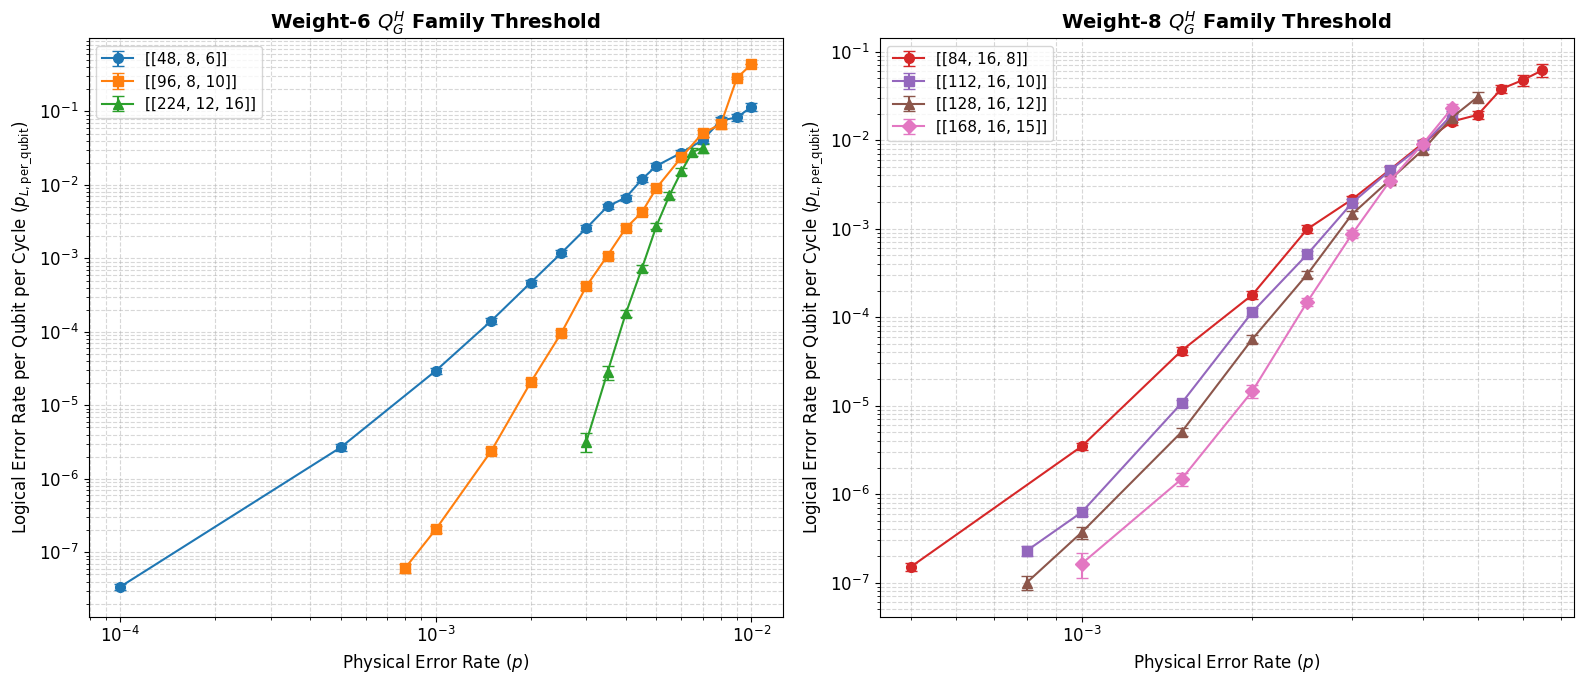

In [78]:

weight_6_codes = {
    "[[48, 8, 6]]":    {'df': df48,  'k': 8,  'color': '#1f77b4', 'marker': 'o'},
    "[[96, 8, 10]]":   {'df': df96,  'k': 8,  'color': '#ff7f0e', 'marker': 's'},
    "[[224, 12, 16]]": {'df': df224, 'k': 12, 'color': '#2ca02c', 'marker': '^'}
}

weight_8_codes = {
    "[[84, 16, 8]]":   {'df': df84,  'k': 16, 'color': '#d62728', 'marker': 'o'},
    "[[112, 16, 10]]": {'df': df112, 'k': 16, 'color': '#9467bd', 'marker': 's'},
    "[[128, 16, 12]]": {'df': df128, 'k': 16, 'color': '#8c564b', 'marker': '^'},
    "[[168, 16, 15]]": {'df': df168, 'k': 16, 'color': '#e377c2', 'marker': 'D'}
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

def plot_family_1(ax, code_dict, title):
    for name, info in code_dict.items():
        df = info['df']
        k = info['k']
        
        if df is None or df.empty:
            print(f"Warning: DataFrame for {name} is empty.")
            continue
            
        # 1. Normalize to per-logical-qubit error rate
        normalized_pL = 1 - (1 - df['total_pL'])**(1/k)
        
        # 2. Propagate the error bars through the normalization equation
        derivative = (1/k) * (1 - df['total_pL'])**((1/k) - 1)
        normalized_pL_err = derivative * df['total_pL_err']
        
        # 3. Plot the curve
        ax.errorbar(df['p'], normalized_pL, yerr=normalized_pL_err, 
                    label=f"{name}", color=info['color'], marker=info['marker'], 
                    linestyle='-', capsize=4, markersize=7)
    
    # Format axes
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Physical Error Rate ($p$)', fontsize=12)
    ax.set_ylabel('Logical Error Rate per Qubit per Cycle ($p_{L,\\mathrm{per\\_qubit}}$)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, which="both", ls="--", alpha=0.5)
    

    ax.legend(fontsize=11)
def plot_family_2(ax, code_dict, title):
    for name, info in code_dict.items():
        df = info['df']
        k = info['k']
        
        if df is None or df.empty:
            print(f"Warning: DataFrame for {name} is empty.")
            continue
            
        # 1. Normalize to per-logical-qubit error rate
        normalized_pL = 1 - (1 - df['total_pL'])**(1/k)
        
        # 2. Propagate the error bars through the normalization equation
        derivative = (1/k) * (1 - df['total_pL'])**((1/k) - 1)
        normalized_pL_err = derivative * df['total_pL_err']
        
        # 3. Plot the curve
        ax.errorbar(df['p'], normalized_pL, yerr=normalized_pL_err, 
                    label=f"{name}", color=info['color'], marker=info['marker'], 
                    linestyle='-', capsize=4, markersize=7)
    
    # Format axes
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Physical Error Rate ($p$)', fontsize=12)
    ax.set_ylabel('Logical Error Rate per Qubit per Cycle ($p_{L,\\mathrm{per\\_qubit}}$)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, which="both", ls="--", alpha=0.5)
    
    # Add Break-even line
    #ax.plot([1e-4, 5e-3], [6e-4, 5e-3], 'k:', alpha=0.7, label='Break-even ($p_L = p$)')
    ax.legend(fontsize=11)

# Generate plots
plot_family_1(ax1, weight_6_codes, 'Weight-6 $Q_G^H$ Family Threshold')
plot_family_2(ax2, weight_8_codes, 'Weight-8 $Q_G^H$ Family Threshold')

plt.tight_layout()
plt.show()

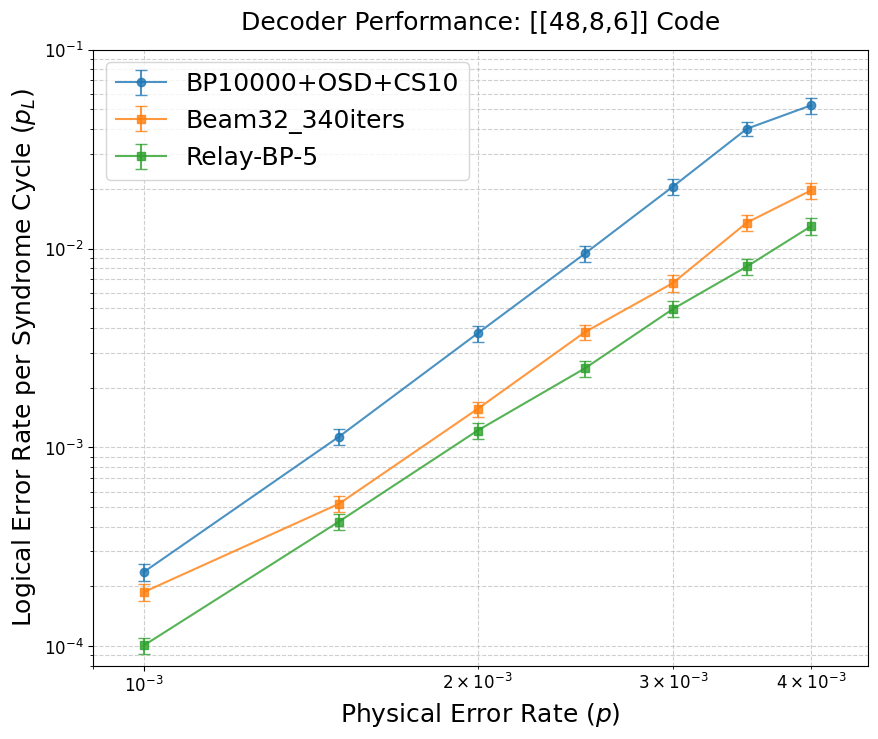

In [79]:
# 1. Filter by specific p values (Modify this list as needed)
desired_p_values = [0.001, 0.0015, 0.002, 0.0025, 0.003, 0.0035, 0.004]

# 2. Desired plotting range bounds 
p_axis_limits = (0.0009, 0.0045)  # (min, max) for x-axis
pL_axis_limits = (8e-5, 10e-2)    # (min, max) for y-axis
# =========================================================================

# Apply filter
if not df48.empty:
    df48 = df48[df48['p'].isin(desired_p_values)]
if not df_48_beam.empty:
    df_48_beam = df_48_beam[df_48_beam['p'].isin(desired_p_values)]
if not df_48_relay.empty:
    df_48_relay = df_48_relay[df_48_relay['p'].isin(desired_p_values)]


# Plotting
plt.figure(figsize=(10, 8))

if not df48.empty:
    plt.errorbar(df48['p'], df48['total_pL'], yerr=df48['total_pL_err'], 
                 label='BP10000+OSD+CS10', fmt='-o', capsize=4, alpha=0.8)
if not df_48_beam.empty:
    plt.errorbar(df_48_beam['p'], df_48_beam['total_pL'], yerr=df_48_beam['total_pL_err'], 
                 label='Beam32_340iters', fmt='-s', capsize=4, alpha=0.8)
if not df_48_relay.empty:
    plt.errorbar(df_48_relay['p'], df_48_relay['total_pL'], yerr=df_48_relay['total_pL_err'], 
                 label='Relay-BP-5', fmt='-s', capsize=4, alpha=0.8)

plt.xscale('log')
plt.yscale('log')

# Apply axis limits
plt.xlim(p_axis_limits)
plt.ylim(pL_axis_limits)

plt.title('Decoder Performance: [[48,8,6]] Code', fontsize=18, pad=15)
plt.xlabel('Physical Error Rate ($p$)', fontsize=18)
plt.ylabel('Logical Error Rate per Syndrome Cycle ($p_L$)', fontsize=18)
plt.legend(fontsize=18)
plt.grid(True, which="both", ls="--", alpha=0.6)

#plt.savefig('plot_decoder_48_8_6_paper.pdf', dpi=600, bbox_inches='tight')
plt.show()

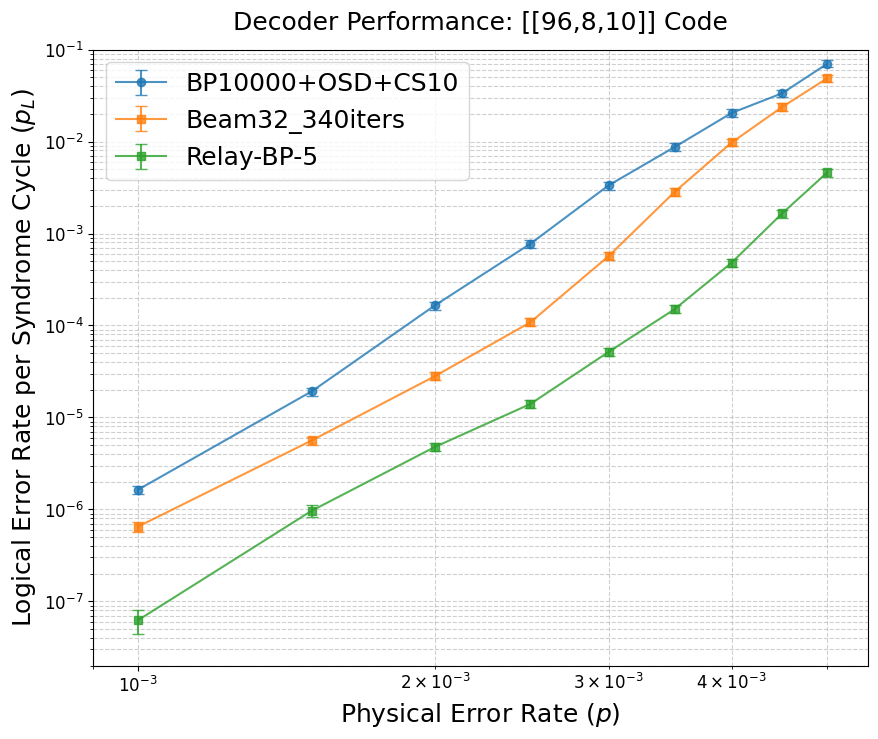

In [80]:
# 1. Filter by specific p values (Modify this list as needed)
desired_p_values = [0.001, 0.0015, 0.002, 0.0025, 0.003, 0.0035, 0.004,0.0045,0.005]
# 2. Desired plotting range bounds 
p_axis_limits = (0.0009, 0.0055)  # (min, max) for x-axis
pL_axis_limits = (0.02e-6, 10e-2)    # (min, max) for y-axis
# =========================================================================

# Apply filter
if not df96.empty:
    df96 = df96[df96['p'].isin(desired_p_values)]
if not df_96_beam.empty:
    df_96_beam = df_96_beam[df_96_beam['p'].isin(desired_p_values)]
if not df_96_relay.empty:
    df_96_relay = df_96_relay[df_96_relay['p'].isin(desired_p_values)]

# Plotting
plt.figure(figsize=(10, 8))

if not df96.empty:
    plt.errorbar(df96['p'], df96['total_pL'], yerr=df96['total_pL_err'], 
                 label='BP10000+OSD+CS10', fmt='-o', capsize=4, alpha=0.8)

if not df_96_beam.empty:
    plt.errorbar(df_96_beam['p'], df_96_beam['total_pL'], yerr=df_96_beam['total_pL_err'], 
                 label='Beam32_340iters', fmt='-s', capsize=4, alpha=0.8)
    
if not df_96_relay.empty:
    plt.errorbar(df_96_relay['p'], df_96_relay['total_pL'], yerr=df_96_relay['total_pL_err'], 
                 label='Relay-BP-5', fmt='-s', capsize=4, alpha=0.8)

plt.xscale('log')
plt.yscale('log')

# Apply axis limits
plt.xlim(p_axis_limits)
plt.ylim(pL_axis_limits)

plt.title('Decoder Performance: [[96,8,10]] Code', fontsize=18, pad=15)
plt.xlabel('Physical Error Rate ($p$)', fontsize=18)
plt.ylabel('Logical Error Rate per Syndrome Cycle ($p_L$)', fontsize=18)
plt.legend(fontsize=18)
plt.grid(True, which="both", ls="--", alpha=0.6)

#plt.savefig('plot_decoder_96_8_10_paper.pdf', dpi=600, bbox_inches='tight')

plt.show()

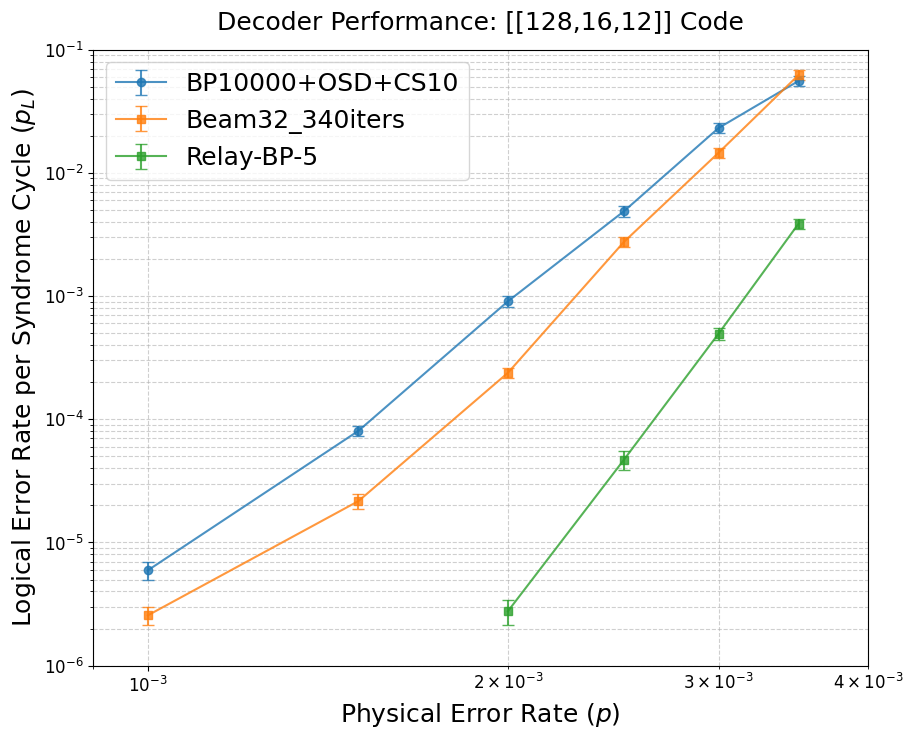

In [81]:
import matplotlib.pyplot as plt

# =========================================================================
# 1. Filter by specific p values 
# (This applies to BPOSD and Beam)
desired_p_values = [0.001, 0.0015, 0.002, 0.0025, 0.003, 0.0035]

# (This applies ONLY to Relay-BP - Modify this list to your exact needs!)
desired_p_values_relay = [0.002, 0.0025, 0.003, 0.0035] 

# 2. Desired plotting range bounds 
p_axis_limits = (0.0009, 0.004)  # (min, max) for x-axis
pL_axis_limits = (1e-6, 10e-2)    # (min, max) for y-axis
# =========================================================================

# Apply filter for BPOSD and Beam
if not df128.empty:
    df128 = df128[df128['p'].isin(desired_p_values)]
if not df_128_beam.empty:
    df_128_beam = df_128_beam[df_128_beam['p'].isin(desired_p_values)]

# Apply specific filter ONLY for Relay-BP
if not df_128_relay.empty:
    df_128_relay = df_128_relay[df_128_relay['p'].isin(desired_p_values_relay)]

# Plotting
plt.figure(figsize=(10, 8))

if not df128.empty:
    plt.errorbar(df128['p'], df128['total_pL'], yerr=df128['total_pL_err'], 
                 label='BP10000+OSD+CS10', fmt='-o', capsize=4, alpha=0.8)

if not df_128_beam.empty:
    plt.errorbar(df_128_beam['p'], df_128_beam['total_pL'], yerr=df_128_beam['total_pL_err'], 
                 label='Beam32_340iters', fmt='-s', capsize=4, alpha=0.8)
                 
if not df_128_relay.empty:
    plt.errorbar(df_128_relay['p'], df_128_relay['total_pL'], yerr=df_128_relay['total_pL_err'], 
                 label='Relay-BP-5', fmt='-s', capsize=4, alpha=0.8)

plt.xscale('log')
plt.yscale('log')

# Apply axis limits
plt.xlim(p_axis_limits)
plt.ylim(pL_axis_limits)

plt.title('Decoder Performance: [[128,16,12]] Code', fontsize=18, pad=15)
plt.xlabel('Physical Error Rate ($p$)', fontsize=18)
plt.ylabel('Logical Error Rate per Syndrome Cycle ($p_L$)', fontsize=18)
plt.legend(fontsize=18)
plt.grid(True, which="both", ls="--", alpha=0.6)

#plt.savefig('plot_decoder_128_16_12_paper.pdf', dpi=600, bbox_inches='tight')
plt.show()